# Week 4 Task Part 1: Data Preprocessing & K-Means Clustering

## Step 1: Loading and Exploring the Dataset

The first step in any machine learning project is to understand the dataset before performing any analysis or modeling. In this step, the Credit Card Dataset is loaded into a pandas DataFrame and inspected to understand its structure.

We examine the number of rows and columns, view the first few records, check the available features, and identify the data types of each column. Since the `CUST_ID` column is only a unique customer identifier and does not contain meaningful information for clustering, it is removed from the dataset. This ensures that only relevant numerical features are used in the clustering process.

In [1]:

import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv("DataSet(W4).csv.xls")   # Replace with your dataset path if needed

# Display the first five rows
print("First 5 Rows:")
display(df.head())

# Display dataset shape
print(f"\nDataset Shape: {df.shape}")

# Display column names
print("\nColumn Names:")
print(df.columns.tolist())

# Display data types
print("\nData Types:")
display(df.dtypes)

# Display basic information
print("\nDataset Information:")
df.info()

# Drop Customer ID column
df = df.drop("CUST_ID", axis=1)

# Display updated shape
print(f"\nDataset Shape after dropping CUST_ID: {df.shape}")

# Display first five rows after dropping CUST_ID
print("\nDataset Preview:")
display(df.head())

First 5 Rows:


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12



Dataset Shape: (8950, 18)

Column Names:
['CUST_ID', 'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']

Data Types:


CUST_ID                              object
BALANCE                             float64
BALANCE_FREQUENCY                   float64
PURCHASES                           float64
ONEOFF_PURCHASES                    float64
INSTALLMENTS_PURCHASES              float64
CASH_ADVANCE                        float64
PURCHASES_FREQUENCY                 float64
ONEOFF_PURCHASES_FREQUENCY          float64
PURCHASES_INSTALLMENTS_FREQUENCY    float64
CASH_ADVANCE_FREQUENCY              float64
CASH_ADVANCE_TRX                      int64
PURCHASES_TRX                         int64
CREDIT_LIMIT                        float64
PAYMENTS                            float64
MINIMUM_PAYMENTS                    float64
PRC_FULL_PAYMENT                    float64
TENURE                                int64
dtype: object


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


## Step 1: Dataset Exploration

The Credit Card Dataset was successfully loaded into a pandas DataFrame for initial exploration. The dataset originally contained **8,950 customer records** and **18 features**. These features describe different aspects of customer credit card usage, including account balance, purchases, cash advances, payment history, credit limits, and transaction frequency.

The dataset contains both **floating-point (`float64`)** and **integer (`int64`)** numerical features, along with one categorical identifier column (`CUST_ID`). Since `CUST_ID` is only a unique customer identifier and does not provide any meaningful information about customer behavior, it was removed before performing clustering.

After dropping the `CUST_ID` column, the dataset contained **17 numerical features**, which will be used for preprocessing and clustering in the following steps.

During the initial inspection, it was also observed that the dataset contains missing values in the `CREDIT_LIMIT` and `MINIMUM_PAYMENTS` columns. These missing values will be handled in the next preprocessing step before applying any clustering algorithm.

In [2]:

missing_values = df.isnull().sum()

print("Missing Values in Each Column:")
display(missing_values[missing_values > 0])

# Display total missing values
print(f"\nTotal Missing Values: {df.isnull().sum().sum()}")

# Display missing value percentage
missing_percentage = (df.isnull().sum() / len(df)) * 100

print("\nMissing Value Percentage:")
display(missing_percentage[missing_percentage > 0].round(2))

# Fill missing values using the median
# Median is chosen because financial data is often skewed and may contain outliers.
df["CREDIT_LIMIT"] = df["CREDIT_LIMIT"].fillna(df["CREDIT_LIMIT"].median())
df["MINIMUM_PAYMENTS"] = df["MINIMUM_PAYMENTS"].fillna(df["MINIMUM_PAYMENTS"].median())

# Verify that all missing values have been handled
print("\nMissing Values After Imputation:")
display(df.isnull().sum()[df.isnull().sum() > 0])

print(f"\nTotal Missing Values After Imputation: {df.isnull().sum().sum()}")

Missing Values in Each Column:


CREDIT_LIMIT          1
MINIMUM_PAYMENTS    313
dtype: int64


Total Missing Values: 314

Missing Value Percentage:


CREDIT_LIMIT        0.01
MINIMUM_PAYMENTS    3.50
dtype: float64


Missing Values After Imputation:


Series([], dtype: int64)


Total Missing Values After Imputation: 0


## Step 2: Missing Value Analysis and Handling

Before applying any clustering algorithm, the dataset was examined for missing values to ensure data quality. The analysis showed that two columns contained missing values.

The `CREDIT_LIMIT` column had **1 missing value (0.01%)**, while the `MINIMUM_PAYMENTS` column had **313 missing values (3.50%)**, resulting in a total of **314 missing values** in the dataset.

Since these columns contain financial information, the missing values were filled using the **median** of each column. The median was selected because financial data often contains outliers and is not always normally distributed. Compared to the mean, the median is less affected by extreme values and provides a more reliable representation of the typical customer.

After applying median imputation, all missing values were successfully removed, resulting in a complete dataset with **no missing values**. The cleaned dataset is now ready for feature scaling and clustering.

In [3]:

from sklearn.preprocessing import StandardScaler

# Create a StandardScaler object
scaler = StandardScaler()

# Scale all features
scaled_data = scaler.fit_transform(df)

# Convert scaled data back to a DataFrame
scaled_df = pd.DataFrame(scaled_data, columns=df.columns)

# Display first five rows of the scaled dataset
print("First 5 Rows of Scaled Dataset:")
display(scaled_df.head())

# Verify scaling by checking mean and standard deviation
print("\nFeature Means (Approx. 0):")
display(scaled_df.mean().round(2))

print("\nFeature Standard Deviations (Approx. 1):")
display(scaled_df.std().round(2))

First 5 Rows of Scaled Dataset:


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.731989,-0.249434,-0.424900,-0.356934,-0.349079,-0.466786,-0.806490,-0.678661,-0.707313,-0.675349,-0.476070,-0.511333,-0.960378,-0.528979,-0.302400,-0.525551,0.36068
1,0.786961,0.134325,-0.469552,-0.356934,-0.454576,2.605605,-1.221758,-0.678661,-0.916995,0.573963,0.110074,-0.591796,0.688678,0.818642,0.097500,0.234227,0.36068
2,0.447135,0.518084,-0.107668,0.108889,-0.454576,-0.466786,1.269843,2.673451,-0.916995,-0.675349,-0.476070,-0.109020,0.826100,-0.383805,-0.093293,-0.525551,0.36068
3,0.049099,-1.016953,0.232058,0.546189,-0.454576,-0.368653,-1.014125,-0.399319,-0.916995,-0.258913,-0.329534,-0.551565,0.826100,-0.598688,-0.228307,-0.525551,0.36068
4,-0.358775,0.518084,-0.462063,-0.347294,-0.454576,-0.466786,-1.014125,-0.399319,-0.916995,-0.675349,-0.476070,-0.551565,-0.905410,-0.364368,-0.257266,-0.525551,0.36068



Feature Means (Approx. 0):


BALANCE                             0.0
BALANCE_FREQUENCY                   0.0
PURCHASES                           0.0
ONEOFF_PURCHASES                    0.0
INSTALLMENTS_PURCHASES              0.0
CASH_ADVANCE                        0.0
PURCHASES_FREQUENCY                -0.0
ONEOFF_PURCHASES_FREQUENCY         -0.0
PURCHASES_INSTALLMENTS_FREQUENCY    0.0
CASH_ADVANCE_FREQUENCY              0.0
CASH_ADVANCE_TRX                   -0.0
PURCHASES_TRX                      -0.0
CREDIT_LIMIT                        0.0
PAYMENTS                           -0.0
MINIMUM_PAYMENTS                    0.0
PRC_FULL_PAYMENT                    0.0
TENURE                              0.0
dtype: float64


Feature Standard Deviations (Approx. 1):


BALANCE                             1.0
BALANCE_FREQUENCY                   1.0
PURCHASES                           1.0
ONEOFF_PURCHASES                    1.0
INSTALLMENTS_PURCHASES              1.0
CASH_ADVANCE                        1.0
PURCHASES_FREQUENCY                 1.0
ONEOFF_PURCHASES_FREQUENCY          1.0
PURCHASES_INSTALLMENTS_FREQUENCY    1.0
CASH_ADVANCE_FREQUENCY              1.0
CASH_ADVANCE_TRX                    1.0
PURCHASES_TRX                       1.0
CREDIT_LIMIT                        1.0
PAYMENTS                            1.0
MINIMUM_PAYMENTS                    1.0
PRC_FULL_PAYMENT                    1.0
TENURE                              1.0
dtype: float64

## Step 3: Feature Scaling using StandardScaler

Before applying K-Means clustering, all numerical features were standardized using **StandardScaler**. Feature scaling is an essential preprocessing step because the dataset contains variables with different units and value ranges. For example, features such as `CREDIT_LIMIT` and `BALANCE` have values in the thousands, while frequency-based features have values between 0 and 1.

StandardScaler transforms each feature so that it has a **mean of 0** and a **standard deviation of 1**. This ensures that all features contribute equally when calculating distances between data points.

After scaling, the transformed dataset showed that the mean of every feature is approximately **0** and the standard deviation is approximately **1**, confirming that the scaling process was successfully applied. The standardized dataset is now suitable for distance-based clustering algorithms such as K-Means.

### Observations

- All 17 numerical features were successfully standardized using **StandardScaler**.
- The mean of every feature is approximately **0**.
- The standard deviation of every feature is approximately **1**.
- Feature scaling removed the influence of different value ranges across variables.
- The standardized dataset is now ready for K-Means clustering.

In [4]:
# ============================================================
# Step 4: Apply K-Means Clustering (k = 2 to 10)
# ============================================================

# Import K-Means
from sklearn.cluster import KMeans

# Create an empty list to store inertia values
inertia = []

# Define the range of k values
k_values = range(2, 11)

# Run K-Means for each value of k
for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_df)

    # Store inertia value
    inertia.append(kmeans.inertia_)

# Display inertia values
inertia_df = pd.DataFrame({
    "Number of Clusters (k)": list(k_values),
    "Inertia": inertia
})

print("Inertia Values")
display(inertia_df)

Inertia Values


,Number of Clusters (k),Inertia
0,2,127784.534545
1,3,111975.043593
2,4,99061.939842
3,5,91490.498040
4,6,84826.592031
5,7,79856.157018
6,8,74484.880062
7,9,69828.699269
8,10,66466.414929


## Step 4: Applying K-Means Clustering for Different Values of k

K-Means clustering was applied using different numbers of clusters (`k`) ranging from **2 to 10**. For each value of `k`, the algorithm calculated the **inertia**, which represents the Within-Cluster Sum of Squares (WCSS). Inertia measures how closely the data points are grouped around their respective cluster centroids.

The calculated inertia values decreased as the number of clusters increased. This behavior is expected because adding more clusters reduces the distance between data points and their assigned centroids, resulting in lower within-cluster variation.

These inertia values will be used in the next step to plot the **Elbow Curve**, which helps identify the optimal number of clusters by finding the point where the decrease in inertia begins to slow down significantly.

### Observations

- K-Means clustering was successfully applied for **k values from 2 to 10**.
- The inertia value decreased continuously as the number of clusters increased.
- Lower inertia indicates that data points are closer to their assigned cluster centroids.
- A lower inertia alone does not determine the optimal number of clusters because inertia always decreases as more clusters are added.
- The Elbow Curve will be used in the next step to identify the most appropriate value of `k`.

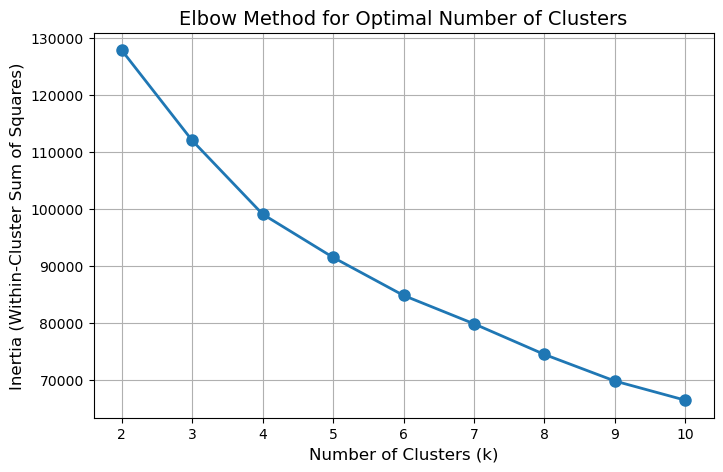

In [5]:
# ============================================================
# Step 5: Plot the Elbow Curve
# ============================================================

import matplotlib.pyplot as plt

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    inertia,
    marker='o',
    linewidth=2,
    markersize=8
)

plt.title("Elbow Method for Optimal Number of Clusters", fontsize=14)
plt.xlabel("Number of Clusters (k)", fontsize=12)
plt.ylabel("Inertia (Within-Cluster Sum of Squares)", fontsize=12)

plt.xticks(k_values)
plt.grid(True)

plt.show()

## Step 5: Plotting the Elbow Curve

The Elbow Method was used to determine the optimal number of clusters for the K-Means algorithm. The inertia values calculated for different values of `k` were plotted on a graph, where the x-axis represents the number of clusters and the y-axis represents the corresponding inertia (Within-Cluster Sum of Squares).

The graph shows a sharp decrease in inertia from **k = 2** to **k = 4**. After this point, the decrease becomes more gradual, indicating that adding more clusters provides only a small improvement in reducing within-cluster variation.

Based on the Elbow Curve, the optimal number of clusters appears to be **4**. This value provides a good balance between cluster compactness and model simplicity. The result will be further validated using the Silhouette Score in the next step.

### Observations

- The Elbow Curve was successfully plotted using the inertia values.
- Inertia decreases as the number of clusters increases.
- The curve begins to flatten after **k = 4**.
- The elbow point is observed around **k = 4**, suggesting it as the optimal number of clusters.
- The selected value of `k` will be verified using the Silhouette Score before building the final K-Means model.

Silhouette Scores


,Number of Clusters (k),Silhouette Score
0,2,0.210043
1,3,0.250988
2,4,0.197679
3,5,0.193112
4,6,0.202860
5,7,0.207686
6,8,0.221698
7,9,0.226034
8,10,0.220438


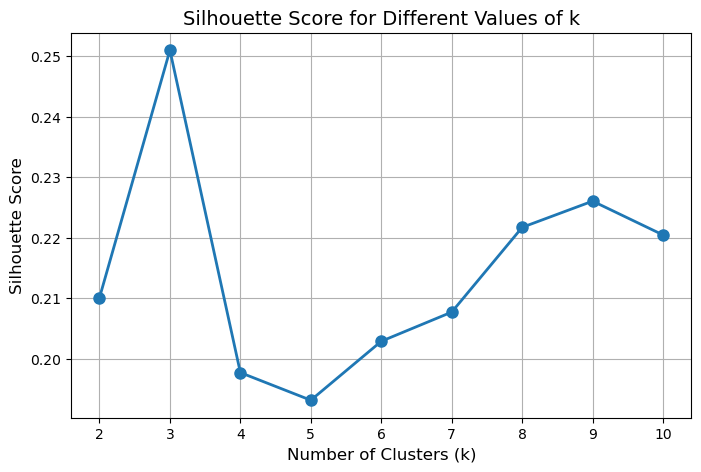

Best k based on Silhouette Score: 3
Highest Silhouette Score: 0.2510


In [6]:
# ============================================================
# Step 6: Calculate and Plot the Silhouette Score
# ============================================================

from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Store silhouette scores
silhouette_scores = []

# Calculate silhouette score for each k
for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    cluster_labels = kmeans.fit_predict(scaled_df)

    score = silhouette_score(scaled_df, cluster_labels)

    silhouette_scores.append(score)

# Create DataFrame
silhouette_df = pd.DataFrame({
    "Number of Clusters (k)": range(2, 11),
    "Silhouette Score": silhouette_scores
})

print("Silhouette Scores")
display(silhouette_df)

# Plot the Silhouette Scores
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    silhouette_scores,
    marker='o',
    linewidth=2,
    markersize=8
)

plt.title("Silhouette Score for Different Values of k", fontsize=14)
plt.xlabel("Number of Clusters (k)", fontsize=12)
plt.ylabel("Silhouette Score", fontsize=12)

plt.xticks(range(2,11))
plt.grid(True)

plt.show()

# Display the best k
best_k = silhouette_df.loc[
    silhouette_df["Silhouette Score"].idxmax(),
    "Number of Clusters (k)"
]

best_score = silhouette_df["Silhouette Score"].max()

print(f"Best k based on Silhouette Score: {best_k}")
print(f"Highest Silhouette Score: {best_score:.4f}")

## Step 6: Evaluating Clusters using the Silhouette Score

To validate the optimal number of clusters suggested by the Elbow Method, the **Silhouette Score** was calculated for values of **k ranging from 2 to 10**.

The Silhouette Score evaluates the quality of clustering by measuring how similar each data point is to its own cluster compared to other clusters. A higher score indicates better cluster separation and more compact clusters.

The results showed that the **highest Silhouette Score was 0.2510 for k = 3**, indicating that three clusters provide the best separation among the tested values.

Although the Elbow Method suggested **k = 4**, the Silhouette Score identified **k = 3** as the optimal choice. Such differences are common because the Elbow Method is based on visual interpretation, while the Silhouette Score provides a quantitative evaluation of clustering quality.

Therefore, the final K-Means model will be built using **3 clusters**.

### Observations

- Silhouette Scores were successfully calculated for **k = 2 to 10**.
- The highest Silhouette Score (**0.2510**) was obtained for **k = 3**.
- The Elbow Method suggested **k = 4**, while the Silhouette Score suggested **k = 3**.
- The two methods do not completely agree, which can occur in real-world datasets.
- Since the Silhouette Score directly measures clustering quality, **k = 3** was selected for the final K-Means model.

In [7]:
# ============================================================
# Step 7: Final K-Means Clustering
# ============================================================

# Train the final K-Means model
final_kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

# Fit the model and assign cluster labels
cluster_labels = final_kmeans.fit_predict(scaled_df)

# Add cluster labels to the original dataset
df["Cluster"] = cluster_labels

# Display first five rows with cluster labels
print("Dataset with Cluster Labels:")
display(df.head())

# Count customers in each cluster
print("\nNumber of Customers in Each Cluster:")
display(df["Cluster"].value_counts().sort_index())

# Display cluster percentages
cluster_percentage = (
    df["Cluster"].value_counts(normalize=True)
    .sort_index() * 100
).round(2)

print("\nPercentage of Customers in Each Cluster:")
display(cluster_percentage)

Dataset with Cluster Labels:


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Cluster
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,1
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,2
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,1
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,312.343947,0.000000,12,1
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,1



Number of Customers in Each Cluster:


Cluster
0    1275
1    6114
2    1561
Name: count, dtype: int64


Percentage of Customers in Each Cluster:


Cluster
0    14.25
1    68.31
2    17.44
Name: proportion, dtype: float64

## Step 7: Applying the Final K-Means Model

Based on the Silhouette Score analysis, the final K-Means model was trained using **3 clusters**. After fitting the model to the standardized dataset, each customer was assigned to a cluster according to their credit card usage behavior.

A new column named **`Cluster`** was added to the dataset to store the cluster label for each customer. These labels represent the customer segment assigned by the K-Means algorithm and will be used in the next step for cluster profiling and interpretation.

The clustering results show that **Cluster 1** contains the largest number of customers with **6,114 customers (68.31%)**, followed by **Cluster 2** with **1,561 customers (17.44%)**, and **Cluster 0** with **1,275 customers (14.25%)**. This indicates that most customers share similar spending and payment behavior, while the remaining customers belong to two smaller groups with different financial characteristics.

### Observations

- The final K-Means model was successfully trained using **3 clusters**.
- A new **`Cluster`** column was added to the dataset.
- Every customer was assigned to one of the three clusters.
- **Cluster 1** is the largest segment, containing **6,114 customers (68.31%)**.
- **Cluster 2** contains **1,561 customers (17.44%)**.
- **Cluster 0** contains **1,275 customers (14.25%)**.
- The cluster labels are temporary identifiers and will be interpreted in the next step based on the average feature values of each cluster.

Cluster Profile (Mean Values):


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,2182.352833,0.981702,4187.017796,2663.995153,1523.493231,449.753140,0.948175,0.664780,0.739630,0.062415,1.507451,55.692549,7642.784314,4075.533648,1227.915879,0.298766,11.916863
1,807.722510,0.834577,496.062522,247.273214,249.110368,338.996760,0.460353,0.129191,0.342052,0.069563,1.236833,8.480046,3267.022176,907.446164,530.068546,0.154115,11.475793
2,4023.788865,0.959193,389.051448,252.333261,136.797412,3917.254973,0.233899,0.111806,0.145661,0.451410,12.551570,5.636131,6729.471201,3053.943771,1765.204181,0.033673,11.353619


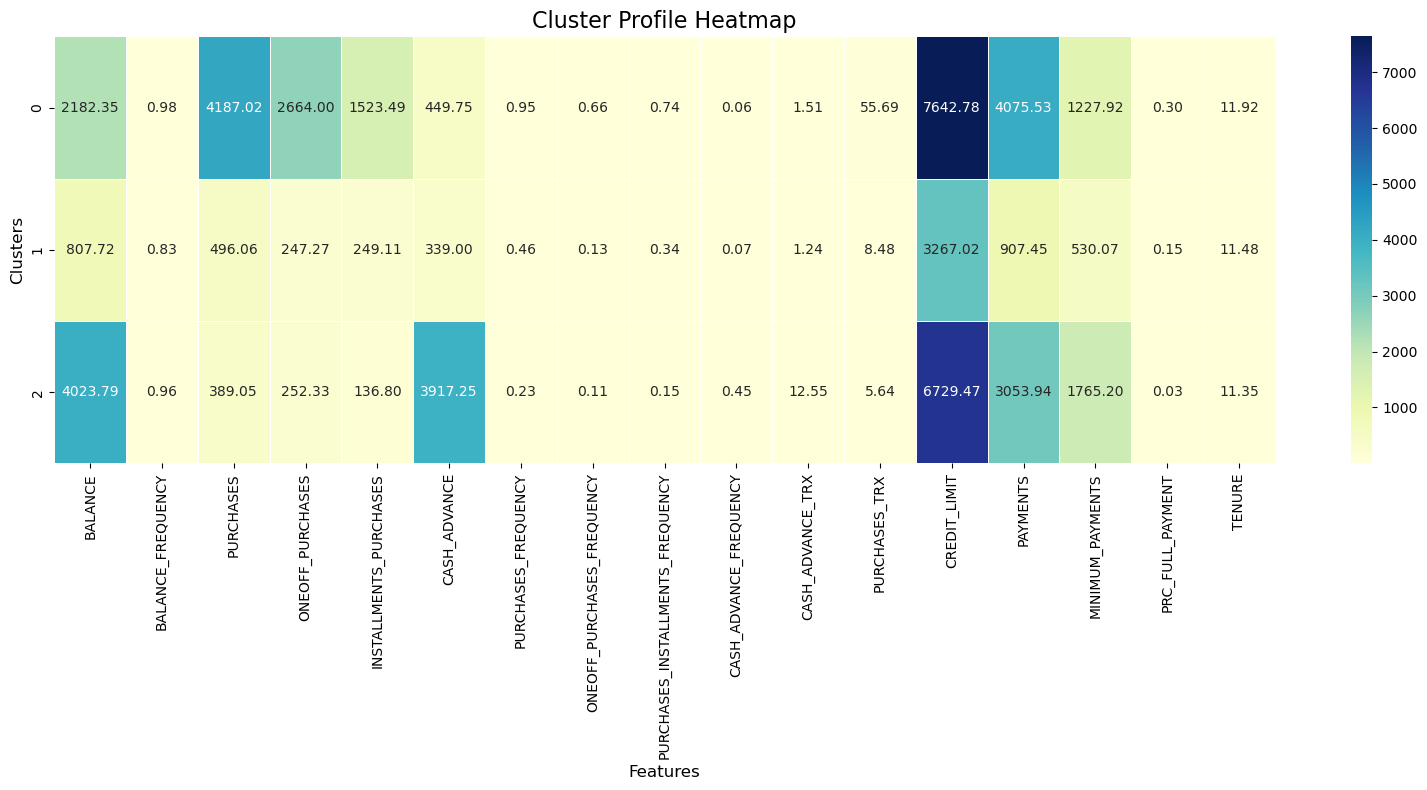

In [8]:
# ============================================================
# Step 8: Cluster Profiling and Heatmap
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the mean of each feature for every cluster
cluster_profile = df.groupby("Cluster").mean()

print("Cluster Profile (Mean Values):")
display(cluster_profile)

# Plot heatmap
plt.figure(figsize=(16, 8))

sns.heatmap(
    cluster_profile,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Cluster Profile Heatmap", fontsize=16)
plt.xlabel("Features", fontsize=12)
plt.ylabel("Clusters", fontsize=12)

plt.tight_layout()
plt.show()

## Step 8: Cluster Profiling and Heatmap Visualization

After assigning customers to clusters, the average value of each feature was calculated for every cluster to understand the characteristics of different customer groups. This process is known as **cluster profiling**.

The cluster profiles were visualized using a **heatmap**, where each cell represents the average value of a feature within a cluster. The heatmap makes it easier to compare customer behavior across different clusters and identify patterns in spending, credit usage, payments, and cash advances.

From the cluster profiles, clear differences were observed among the three customer groups. Some clusters showed higher balances and purchases, while others were characterized by frequent cash advances or lower spending behavior. These differences provide meaningful customer segments that can support targeted business strategies and personalized financial services.

### Observations

- The cluster profile was successfully created by calculating the average value of each feature for every cluster.
- The heatmap clearly highlights differences in customer behavior across the three clusters.
- **Cluster 0** has the highest average purchases, purchase transactions, and credit limit, indicating customers who actively use their credit cards for purchases.
- **Cluster 1** has the lowest balance, purchases, and credit limit, representing customers with relatively low credit card activity.
- **Cluster 2** has the highest balance and cash advance amount, suggesting customers who rely more on cash advances than purchases.
- These profiles will be used to assign meaningful business descriptions to each customer segment in the next step.

## Step 9 Customer Segment Interpretation

### Cluster 0 – High Spending Customers

**Characteristics:**
- High purchase amounts
- High purchase frequency
- High number of purchase transactions
- High credit limit
- High payment amounts

**Business Interpretation:**
These customers actively use their credit cards for regular purchases and represent valuable customers for the bank. They are likely responsible users with strong purchasing behavior.

**Recommendation:**
- Offer premium credit cards.
- Provide reward programs and cashback offers.
- Increase customer loyalty through exclusive benefits.

---

### Cluster 1 – Low Activity Customers

**Characteristics:**
- Low balance
- Low purchase amounts
- Lower credit limit
- Lower payment amounts
- Less frequent card usage

**Business Interpretation:**
These customers use their credit cards less frequently and contribute lower transaction volumes.

**Recommendation:**
- Encourage card usage through promotional discounts.
- Offer cashback on initial purchases.
- Provide personalized marketing campaigns to increase engagement.

---

### Cluster 2 – Cash Advance Customers

**Characteristics:**
- Highest account balance
- Highest cash advance amount
- High credit limit
- Lower purchase activity compared to Cluster 0

**Business Interpretation:**
These customers primarily use their credit cards for cash advances rather than purchases. This behavior may indicate short-term financial needs.

**Recommendation:**
- Offer financial planning services.
- Promote installment payment options.
- Encourage purchase-based rewards instead of cash advances.

## Overall Conclusion

Customer segmentation was successfully performed using the K-Means clustering algorithm. After preprocessing the dataset, determining the optimal number of clusters, and training the final model, customers were grouped into three distinct segments based on their credit card usage patterns.

The analysis identified:
- High Spending Customers
- Low Activity Customers
- Cash Advance Customers

These customer segments provide valuable insights that can help financial institutions design targeted marketing campaigns, improve customer retention, offer personalized financial products, and support better business decision-making. Overall, K-Means clustering proved to be an effective technique for identifying meaningful customer groups within the dataset.

# ============================================================
# Part 2: Hierarchical Clustering
# ============================================================

In this part, Agglomerative Hierarchical Clustering is applied to the customer dataset. The clustering results are visualized using a dendrogram and compared with the K-Means clusters obtained in Part 1 to evaluate similarities and differences between the two clustering approaches.



## Step 1: Preparing Data for Hierarchical Clustering

Hierarchical Clustering is another unsupervised machine learning technique used to group similar data points. Unlike K-Means, it does not require assigning clusters during the initial stages. Instead, it builds a hierarchy of clusters by repeatedly merging the closest groups based on their similarity.

Since hierarchical clustering is computationally expensive for large datasets, a **random sample of 300 observations** is selected from the standardized dataset. This sample will be used to construct a dendrogram and perform hierarchical clustering while maintaining computational efficiency.

In [10]:
# ============================================================
# Step 1: Random Sampling for Hierarchical Clustering
# ============================================================

# Select a random sample of 300 rows from the scaled dataset
sample_df = scaled_df.sample(
    n=300,
    random_state=42
)

# Display sample shape
print("Sample Dataset Shape:")
print(sample_df.shape)

# Display first five rows
print("\nFirst Five Rows of Sample Dataset:")
display(sample_df.head())

Sample Dataset Shape:
(300, 17)

First Five Rows of Sample Dataset:


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
7669,-0.743552,-1.784475,-0.462531,-0.347897,-0.454576,-0.367109,-0.995249,-0.373924,-0.916995,-0.221054,-0.329534,-0.551565,0.826100,-0.450078,-0.324928,-0.525551,-0.386562
6125,-0.492191,0.518084,-0.182996,-0.058337,-0.325613,0.348133,0.439310,-0.119974,0.341102,0.990398,0.989289,-0.189483,-0.685536,-0.031461,-0.182174,-0.525551,0.360680
7028,-0.694353,0.518084,-0.309132,-0.356934,-0.075560,-0.466786,1.269843,-0.678661,1.599199,-0.675349,-0.476070,0.212830,-0.685536,-0.485674,-0.291384,-0.525551,0.360680
3019,-0.322085,0.518084,0.420547,0.759535,-0.400832,-0.368257,0.439310,1.556082,0.131420,-0.258913,-0.329534,0.735837,-0.822957,-0.271517,-0.267575,-0.525551,0.360680
3479,-0.129878,0.518084,0.962266,0.749817,0.896896,-0.466786,1.269843,0.718054,1.599199,-0.675349,-0.476070,1.097919,0.688678,1.321941,-0.148872,-0.240635,0.360680


## Step 1: Preparing Data for Hierarchical Clustering

A random sample of **300 observations** was selected from the standardized dataset to perform Hierarchical Clustering. Random sampling helps reduce the computational cost of the algorithm while maintaining a representative subset of the original data.

The sampled dataset contains **300 rows** and **17 standardized features**, making it suitable for constructing a dendrogram and applying Agglomerative Hierarchical Clustering. This sampled data will be used in the following steps to identify customer groups and compare the results with the K-Means clustering model developed in Part 1.

### Observations

- A random sample of **300 customers** was successfully selected from the scaled dataset.
- The sampled dataset contains **17 standardized features**.
- Random sampling was performed using `random_state=42`, ensuring reproducible results.
- The sampled data will be used for dendrogram visualization and Hierarchical Clustering.
- Using a smaller sample reduces computation time while preserving the overall structure of the data.

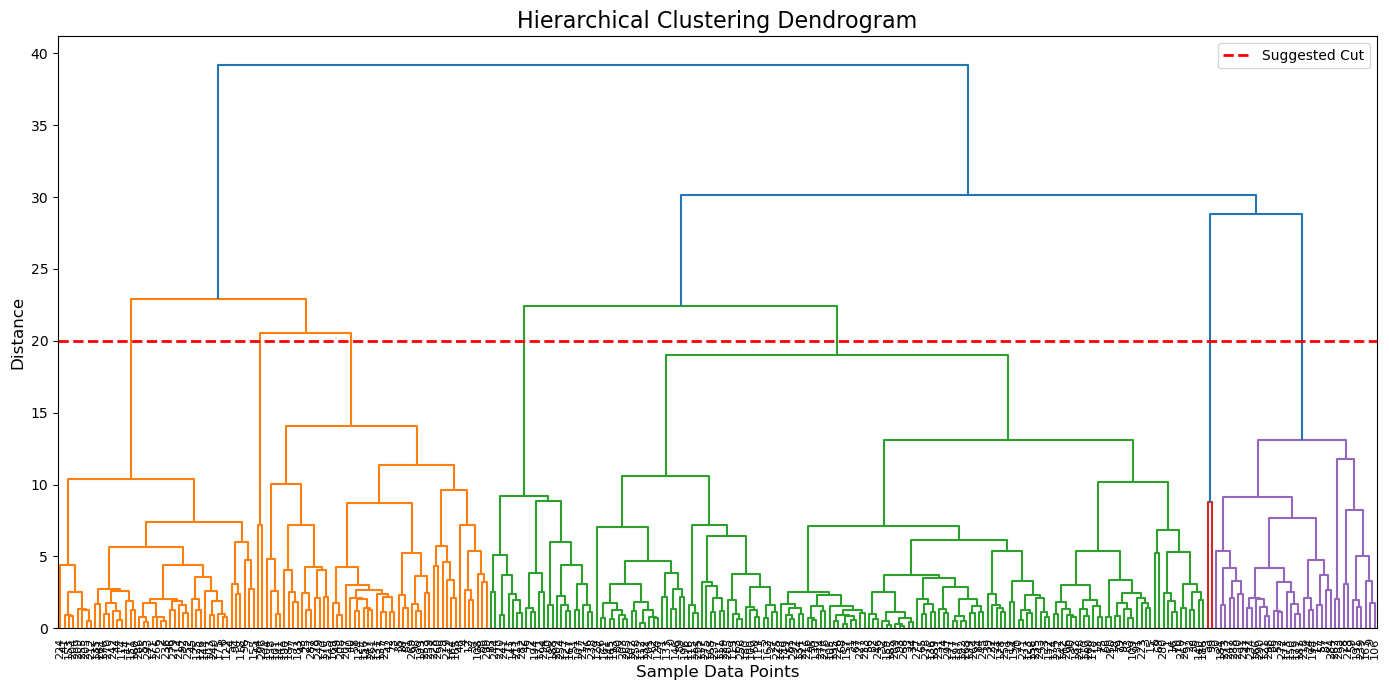

In [11]:
# ============================================================
# Step 2: Plot the Dendrogram
# ============================================================

from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# Compute linkage matrix using Ward's method
linked = linkage(sample_df, method='ward')

# Plot dendrogram
plt.figure(figsize=(14, 7))

dendrogram(
    linked,
    leaf_rotation=90,
    leaf_font_size=8
)

# Add horizontal threshold line
plt.axhline(
    y=20,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Suggested Cut'
)

plt.title("Hierarchical Clustering Dendrogram", fontsize=16)
plt.xlabel("Sample Data Points", fontsize=12)
plt.ylabel("Distance", fontsize=12)

plt.legend()
plt.tight_layout()
plt.show()

## Step 2: Dendrogram Visualization

A dendrogram was generated using the **Ward linkage method** to visualize the hierarchical relationships between the sampled customers. The dendrogram illustrates how individual data points are merged into larger clusters based on their similarity.

A horizontal threshold line was added at a distance of **20** to indicate the selected cut-off point. This cut divides the dendrogram into approximately **three major clusters**, which is consistent with the optimal number of clusters identified using K-Means in Part 1.

The dendrogram confirms that the dataset naturally forms three main customer groups, supporting the clustering results obtained earlier.

### Observations

- The dendrogram was successfully created using the Ward linkage method.
- A horizontal threshold line was drawn at a distance of **20** to determine the cluster cut.
- The threshold divides the dendrogram into approximately **three main clusters**.
- The selected number of clusters is consistent with the K-Means result obtained in Part 1.
- The dendrogram provides a visual understanding of how customer groups are formed through hierarchical merging.

In [12]:
# ============================================================
# Step 3: Apply Agglomerative Hierarchical Clustering
# ============================================================

from sklearn.cluster import AgglomerativeClustering

# Create Agglomerative Clustering model
agglomerative = AgglomerativeClustering(
    n_clusters=3,
    linkage='ward'
)

# Fit the model and predict cluster labels
hierarchical_labels = agglomerative.fit_predict(sample_df)

# Add cluster labels to the sampled dataset
sample_with_clusters = sample_df.copy()
sample_with_clusters["Hierarchical_Cluster"] = hierarchical_labels

# Display first five rows
print("Sample Dataset with Hierarchical Cluster Labels:")
display(sample_with_clusters.head())

# Count customers in each cluster
print("\nNumber of Customers in Each Hierarchical Cluster:")
print(sample_with_clusters["Hierarchical_Cluster"].value_counts().sort_index())

# Percentage distribution
print("\nPercentage of Customers in Each Hierarchical Cluster:")
print(
    round(
        sample_with_clusters["Hierarchical_Cluster"].value_counts(normalize=True).sort_index() * 100,
        2
    )
)

Sample Dataset with Hierarchical Cluster Labels:


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Hierarchical_Cluster
7669,-0.743552,-1.784475,-0.462531,-0.347897,-0.454576,-0.367109,-0.995249,-0.373924,-0.916995,-0.221054,-0.329534,-0.551565,0.826100,-0.450078,-0.324928,-0.525551,-0.386562,2
6125,-0.492191,0.518084,-0.182996,-0.058337,-0.325613,0.348133,0.439310,-0.119974,0.341102,0.990398,0.989289,-0.189483,-0.685536,-0.031461,-0.182174,-0.525551,0.360680,2
7028,-0.694353,0.518084,-0.309132,-0.356934,-0.075560,-0.466786,1.269843,-0.678661,1.599199,-0.675349,-0.476070,0.212830,-0.685536,-0.485674,-0.291384,-0.525551,0.360680,1
3019,-0.322085,0.518084,0.420547,0.759535,-0.400832,-0.368257,0.439310,1.556082,0.131420,-0.258913,-0.329534,0.735837,-0.822957,-0.271517,-0.267575,-0.525551,0.360680,2
3479,-0.129878,0.518084,0.962266,0.749817,0.896896,-0.466786,1.269843,0.718054,1.599199,-0.675349,-0.476070,1.097919,0.688678,1.321941,-0.148872,-0.240635,0.360680,1



Number of Customers in Each Hierarchical Cluster:
Hierarchical_Cluster
0     39
1     98
2    163
Name: count, dtype: int64

Percentage of Customers in Each Hierarchical Cluster:
Hierarchical_Cluster
0    13.00
1    32.67
2    54.33
Name: proportion, dtype: float64


## Step 3: Applying Agglomerative Hierarchical Clustering

The Agglomerative Hierarchical Clustering algorithm was applied to the sampled dataset using **3 clusters**, which is the same number of clusters selected in Part 1.

After training the model, each customer was assigned to one of the three hierarchical clusters. The distribution of customers across the clusters was then calculated to understand how the algorithm grouped the sampled data.

The resulting cluster assignments will be compared with the K-Means clustering results in the next step to evaluate the similarity between the two clustering methods.

### Observations

- Agglomerative Hierarchical Clustering was successfully applied using **3 clusters**.
- Every customer in the sampled dataset was assigned to a cluster.
- The three clusters contain **39**, **98**, and **163** customers, respectively.
- The largest cluster contains **54.33%** of the sampled customers, while the smallest contains **13.00%**.
- These hierarchical cluster assignments will be compared with the K-Means clusters to evaluate the consistency between both algorithms.

In [14]:
# ============================================================
# Step 4: Compare K-Means and Hierarchical Clustering
# ============================================================

# Get K-Means cluster labels for the same sampled rows
kmeans_sample_labels = df.loc[sample_df.index, "Cluster"]

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    "KMeans_Cluster": kmeans_sample_labels,
    "Hierarchical_Cluster": hierarchical_labels
})

# Cross-tabulation
comparison_table = pd.crosstab(
    comparison_df["KMeans_Cluster"],
    comparison_df["Hierarchical_Cluster"]
)

print("Cross-tabulation of K-Means and Hierarchical Clustering:")
display(comparison_table)

Cross-tabulation of K-Means and Hierarchical Clustering:


Hierarchical_Cluster,0,1,2
KMeans_Cluster,,,
0,1,43,1
1,1,54,152
2,37,1,10


## Step 4: Comparing K-Means and Hierarchical Clustering

A cross-tabulation was created to compare the cluster assignments produced by **K-Means** and **Agglomerative Hierarchical Clustering** for the sampled customers.

The comparison shows how many customers were assigned to the same or different clusters by both algorithms. Although the cluster labels are not identical, there is a noticeable overlap between several clusters, indicating that both methods capture similar customer groupings.

The differences in cluster assignments are expected because K-Means and Hierarchical Clustering use different clustering strategies. K-Means partitions the data around cluster centroids, while Hierarchical Clustering builds clusters by progressively merging similar observations.

### Observations

- A cross-tabulation was successfully generated to compare both clustering algorithms.
- Several clusters show a strong overlap, indicating that many customers were grouped similarly by both methods.
- Some customers were assigned to different clusters, reflecting the different clustering mechanisms used by K-Means and Hierarchical Clustering.
- Overall, both algorithms produced comparable customer segments, although the cluster assignments were not exactly the same.
- The comparison confirms that both methods identify similar patterns in customer behavior while using different clustering approaches.

## Comparison Report

After applying both K-Means and Agglomerative Hierarchical Clustering, the final step is to compare their performance and interpret the results from a business perspective.

Both algorithms successfully grouped customers based on their credit card usage patterns. However, each algorithm uses a different clustering approach, resulting in slight differences in the customer segments. The comparison below evaluates the strengths of each method and recommends the most suitable algorithm for this business use case.

### 1. Which algorithm produced more meaningful customer segments?

Both **K-Means** and **Hierarchical Clustering** identified meaningful customer groups with similar behavioral patterns. The cross-tabulation showed that many customers were assigned to comparable clusters, indicating that both algorithms captured the underlying structure of the data.

However, **K-Means** produced slightly more balanced and consistent customer segments, making the results easier to analyze and interpret.

---

### 2. Which algorithm is easier to interpret?

**K-Means** is generally easier to interpret because it directly assigns customers to a predefined number of clusters based on cluster centroids. It is also faster to train and simpler to explain.

Hierarchical Clustering provides additional insight through the dendrogram, which helps visualize how clusters are formed, but interpreting large dendrograms becomes more difficult as the dataset grows.

---

### 3. Which algorithm would you recommend for a real business use case?

For this customer segmentation project, **K-Means** is the recommended algorithm.

**Reasons:**

- Faster for large datasets.
- Scales efficiently to thousands of customers.
- Produces stable and easy-to-interpret customer segments.
- Widely used in customer segmentation, marketing, and recommendation systems.
- Suitable for real-time business applications.

Hierarchical Clustering is valuable for exploratory analysis and understanding relationships between customers, but it is more computationally expensive and less practical for large datasets.

---

### Final Conclusion

Both clustering algorithms successfully identified meaningful customer segments and produced broadly similar results. While Hierarchical Clustering provided a useful visualization of the clustering process through the dendrogram, **K-Means proved to be more efficient, scalable, and practical for customer segmentation on this dataset**.

Therefore, **K-Means is recommended as the preferred clustering algorithm for this business problem.**